# Chatbot with HITL (Human in the Loop)

Agent 처리도중 사람의 개입이 필요한 경우 iterrupt처리할 수 있다.
- 사람의 개입(tool)
- 사람 메세지(command)로 대화를 재개할 수 있다.

In [ ]:
!pip install langchain langgraph langchain-openai langchain-community langchain-tavily -Uq

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['TAVILY_API_KEY'] = os.getenv("tavily_key")

## 도구 정의

In [ ]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)
tavily_tool.invoke('랭그래프에서 노드란 무엇인가요?')

{'query': '랭그래프에서 노드란 무엇인가요?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.gpters.org/dev/post/following-langgraph-lesson-2creating-qk95fMuCHCZEzWN',
   'title': '랭그래프(LangGraph) 따라하기 2강_그래프와 챗봇 만들기 - 지피터스',
   'content': '첫 번째 인수는 고유한 노드 이름입니다. 두 번째 인수는 언제든지 호출될 함수 또는 객체입니다. edge 추가 (선 긋기).',
   'score': 0.91964257,
   'raw_content': None},
  {'url': 'https://m.blog.naver.com/pjt3591oo/223861729229',
   'title': 'langgraph 소개 및 기본개념 : 네이버 블로그',
   'content': '각 노드는 특정 작업(LLM 호출, 도구 사용, 데이터 처리 등)을 수행하며, 이는 파이썬 함수 또는 LCEL Runnable로 정의할 수 있습니다. documents = [ f"{query}에 대한 문서 1: LangGraph는 상태 관리에 유용합니다.", f"{query}에 대한 문서 2: 노드와 엣지로 그래프를 정의합니다.", ] print(f"검색된 문서: {documents}") # 상태 업데이트: \'documents\' 키에 검색 결과 저장 return {"documents": documents} def summarize\\_documents(state: SearchSummarizeState) -> dict: """검색된 문서를 요약하는 (가짜) 함수""" print(f"--- 노드: 요약 수행 ---") documents = state[\'documents\'] # 실제로는 여기서 LLM 요약 Chain을 호출합니다. summary = f

## 사람개입 도구

In [ ]:
from langchain_core.tools import tool
from langgraph.types import interrupt

@tool
def human_assist(query):
    """사람의 개입이 필요하면 이 도구를 사용하세요."""
    # interrupt: graph 수행을 사람의 응답(commna)가 도착할때까지 대기
    human_response = interrupt({'query': query})
    return human_response['data']

## 그래프 구성

In [ ]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

class State(TypedDict):
    messages: Annotated[List, add_messages]

llm = init_chat_model('gpt-4.1-mini')
tools = [tavily_tool, human_assist]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

In [ ]:
# 인메모리 객체
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

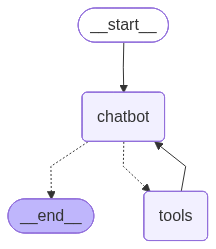

In [ ]:
# graph 생성
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END

tool_node = ToolNode(tools)

workflow = StateGraph(State)

workflow.add_node('chatbot', chatbot)
workflow.add_node('tools', tool_node)

workflow.add_edge(START, 'chatbot')
workflow.add_conditional_edges('chatbot', tools_condition)
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile(checkpointer=memory)
graph

## 챗봇 실행

In [ ]:
# snapshot함수
from pprint import pprint

def print_snapshot(graph, config):
    snapshot = graph.get_state(config)

    print('Messages: ')
    if 'messages' in snapshot.values:
        pprint(snapshot.values['messages'])
    else:
        print('No messages...')

    # 다음 실행 노드 확인
    print(f'Next: {snapshot.next}') # 다음노드가 있으면 확인가능, () END를 의미(graph 종료)

print_snapshot(graph, {'configurable': {'thread_id': 'user1'}})

Messages: 
No messages...
Next: ()


In [ ]:
# 사람개입이 필요없는 대화시작
user1_config = {'configurable': {'thread_id': 'user1'}}
state = {'messages': [('human', '멀티에이젼트 개발을 위한 langgraph의 특징이 무엇인가요?')]}
response = graph.invoke(state, user1_config)
print(response['messages'][-1].content)

LangGraph는 LLM 기반의 에이전트 시스템을 개발하기 위한 라이브러리로, 멀티 에이전트 개발에 다음과 같은 특징이 있습니다:

1. 에이전트 시스템 구성 요소: Tool, Action, Memory, Planning 등을 각각 별도의 에이전트로 만들고, 라우팅 에이전트를 통해 고객을 직접 응대하는 멀티 에이전트 방식으로 구현 가능.
2. 그래프 구조 기반: 에이전트 시스템을 그래프 구조로 구성하여 각 에이전트가 독립된 Prompt, LLM, Tools, 비즈니스 로직(상태 포함)을 가지며 협업하는 구조를 지원.
3. 멀티 에이전트 설계 고려사항: 각 에이전트의 역할 및 태스크와 에이전트 간의 연결을 설계하는 데 중점.
4. 복잡한 의사결정 및 비즈니스 로직을 자연스럽게 설계할 수 있어, 예를 들어 고객 서비스 봇, 코드 리뷰어, 문서화, 테스트 등 다양한 작업을 에이전트들이 협력하여 수행 가능.
5. 실시간 정보 업데이트와 여러 문서 간 교차 검증이 가능해 동적 시스템 구축에 적합.

즉, LangGraph는 멀티 에이전트가 협력해 복잡한 워크플로우를 수행할 수 있도록 그래프 구조로 유연하고 확장성 있게 설계된 플랫폼입니다.


In [ ]:
print_snapshot(graph, user1_config)

Messages: 
[HumanMessage(content='멀티에이젼트 개발을 위한 langgraph의 특징이 무엇인가요?', additional_kwargs={}, response_metadata={}, id='e0e278f2-a946-4763-9ec5-e0ad55211be9'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1235, 'total_tokens': 1261, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_75546bd1a7', 'id': 'chatcmpl-D7Mkui0yseNIA9fBHe0Nt06dYvLlE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c42da-5828-7a32-819a-911d096d7858-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'langgraph 특징 멀티에이전트 개발'}, 'id': 'call_A5JOJAKdRsWP2DToNUOyvqkb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata=

In [ ]:
# 사람개입이 필요한 대화 시작
from langchain_core.prompts import ChatPromptTemplate

system_prompt = """
**Instruction**
사용자는 케이크 주문, 메뉴 문의, 매장 정보 등을 챗봇에 요청할 수 있다.
챗봇은 친절하고 정확하게 답변한다.

**Context**
당신은 프리미엄 케이크샵의 공식 챗봇이다.
- 운영 시간: 매일 09:00–21:00
- 주요 메뉴: 생크림 케이크, 초코 케이크, 치즈 케이크, 시즌 한정 케이크
- 매장 위치: 서울 강남구 신사동 123-45
- 연락처: 02-1234-5678

**Example**
> **User:** “다음 주 수요일 오후 3시에 케이크 예약 가능한가요?”
> **Bot:** “안녕하세요! 다음 주 수요일(2025년 7월 16일) 오후 3시에 예약 가능합니다. 예약을 원하시면 성함과 연락처를 알려주세요.”

**Output Indicator**
- 챗봇 응답은 한 문단 이내로 간결하게 제시한다.
- 필요한 경우 날짜·시간은 YYYY년 M월 D일 형식으로 명시한다.
- 추가 질문이 필요할 때에는 “추가로 궁금하신 점이 있으면 말씀해주세요.” 로 마무리한다.
- 그외 답변하기 어려운 경우, human_assist 도구를 사용하여 인간의 도움을 요청한다.
"""
user_prompt = '당근케익 4호가 홈페이지에서 구매가 안되는데, 매니져님께 구매가능여부를 묻고 싶어요.'
prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    ('human', '{user_prompt}')
])

state = {'messages': prompt.format_messages(user_prompt=user_prompt)}
response = graph.invoke(state, user1_config)
print(response['messages'][-1].content)

In [ ]:
# 스냅샷확인
print_snapshot(graph, user1_config)

Messages: 
[HumanMessage(content='멀티에이젼트 개발을 위한 langgraph의 특징이 무엇인가요?', additional_kwargs={}, response_metadata={}, id='e0e278f2-a946-4763-9ec5-e0ad55211be9'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1235, 'total_tokens': 1261, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_75546bd1a7', 'id': 'chatcmpl-D7Mkui0yseNIA9fBHe0Nt06dYvLlE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c42da-5828-7a32-819a-911d096d7858-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'langgraph 특징 멀티에이전트 개발'}, 'id': 'call_A5JOJAKdRsWP2DToNUOyvqkb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata=

In [ ]:
# 사람 개입 코드
from langgraph.types import Command

human_response = '''
물론입니다. 구매가능하시고요, 홈페이지 구매가능하도록 바로 조치해드릴게요.
가격은 15만원입니다. 감사합니다.
'''
command = Command(resume={'data': human_response})
response = graph.invoke(command, user1_config)
print(response['messages'][-1].content)

안녕하세요! 당근케익 4호는 구매 가능하며, 현재 홈페이지에서도 구매할 수 있도록 바로 조치 중입니다. 가격은 15만원입니다. 추가로 궁금하신 점이 있으면 말씀해주세요.


In [ ]:
print_snapshot(graph, user1_config)

Messages: 
[HumanMessage(content='멀티에이젼트 개발을 위한 langgraph의 특징이 무엇인가요?', additional_kwargs={}, response_metadata={}, id='e0e278f2-a946-4763-9ec5-e0ad55211be9'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 1235, 'total_tokens': 1261, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_75546bd1a7', 'id': 'chatcmpl-D7Mkui0yseNIA9fBHe0Nt06dYvLlE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c42da-5828-7a32-819a-911d096d7858-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'langgraph 특징 멀티에이전트 개발'}, 'id': 'call_A5JOJAKdRsWP2DToNUOyvqkb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata=